#Skin Cancer Classification and Segmentation🎗️

##Import Libraries and Dataset

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-1

In [2]:
!pip install torchsummary

In [3]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import kagglehub
import torchvision.transforms.functional as F
import random
from sklearn.utils.class_weight import compute_class_weight
from torchmetrics.detection import IntersectionOverUnion
from torchmetrics.segmentation import DiceScore

path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ham1000-segmentation-and-classification


##Load CSV File and Print Head

In [4]:
# Load CSV File
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(df.head())
df.dropna(inplace=True)  # Drop missing values if any



          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0


##Define Image and Mask Paths and Remove Corrupt Data


In [5]:
image_dir = os.path.join(path, "images")
mask_dir = os.path.join(path, "masks")
class_names = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

# Convert one-hot encoding to integer labels
df["label"] = df[class_names].idxmax(axis=1).map(lambda x: class_names.index(x))


# Create lists of image paths and labels
images = df["image"].apply(lambda x: os.path.join(image_dir, x + ".jpg")).tolist()
masks = df["image"].apply(lambda x: os.path.join(mask_dir, x + "_segmentation.png")).tolist()
labels = df["label"].tolist()  # Now correctly using integer class labels

for i in range(5):
  print(f"Example Image Path {i}: {images[i]}")
  print(f"Example Mask Path {i}: {masks[i]}")



valid_samples = []
for img, mask in zip(images, masks):
    try:
        if os.path.exists(img) and os.path.exists(mask):
            Image.open(img).verify()
            Image.open(mask).verify()
            valid_samples.append((img, mask))
    except:
        print(f"Corrupt file detected: {img} or {mask}")

images, masks = zip(*valid_samples) if valid_samples else ([], [])
valid_image_names = [os.path.basename(p).replace(".jpg", "") for p in images]
labels = [df[df["image"] == name]["label"].values[0] for name in valid_image_names]


Example Image Path 0: /kaggle/input/ham1000-segmentation-and-classification/images/ISIC_0024306.jpg
Example Mask Path 0: /kaggle/input/ham1000-segmentation-and-classification/masks/ISIC_0024306_segmentation.png
Example Image Path 1: /kaggle/input/ham1000-segmentation-and-classification/images/ISIC_0024307.jpg
Example Mask Path 1: /kaggle/input/ham1000-segmentation-and-classification/masks/ISIC_0024307_segmentation.png
Example Image Path 2: /kaggle/input/ham1000-segmentation-and-classification/images/ISIC_0024308.jpg
Example Mask Path 2: /kaggle/input/ham1000-segmentation-and-classification/masks/ISIC_0024308_segmentation.png
Example Image Path 3: /kaggle/input/ham1000-segmentation-and-classification/images/ISIC_0024309.jpg
Example Mask Path 3: /kaggle/input/ham1000-segmentation-and-classification/masks/ISIC_0024309_segmentation.png
Example Image Path 4: /kaggle/input/ham1000-segmentation-and-classification/images/ISIC_0024310.jpg
Example Mask Path 4: /kaggle/input/ham1000-segmentation-

##Split Data

In [6]:
# Time to Split
train_imgs, temp_imgs, train_labels, temp_labels, train_masks, temp_masks = train_test_split(
    images, labels, masks, test_size=0.3, random_state=42, stratify=labels
)
val_imgs, test_imgs, val_labels, test_labels, val_masks, test_masks = train_test_split(
    temp_imgs, temp_labels, temp_masks, test_size=0.5, random_state=42, stratify=temp_labels
)
# Print dataset sizes
print(f"Dataset size: {len(df)}")
print(f"Training size: {len(train_imgs)}")
print(f"Validation size: {len(val_imgs)}")
print(f"Test size: {len(test_imgs)}")


Dataset size: 10015
Training size: 7010
Validation size: 1502
Test size: 1503


##Count number of Occurence of Each Label


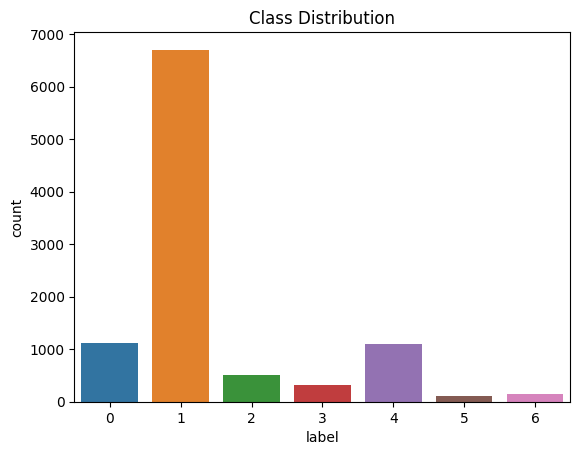

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.show()


In [8]:
from tqdm import tqdm
from collections import Counter
import torch

print("Computing segmentation class weights (optimized)...")

pixel_counter = Counter()

for mask_path in tqdm(train_masks):
    mask = Image.open(mask_path).convert("L")
    mask = F.resize(mask, (224, 224), interpolation=Image.NEAREST)
    mask_np = np.array(mask).astype(np.uint8)
    pixel_counter.update(mask_np.flatten().tolist())

classes = np.array(sorted(pixel_counter.keys()))
counts = np.array([pixel_counter[c] for c in classes])
total = counts.sum()

class_weights_segmentation = total / (len(classes) * counts)

# Define device here
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_segmentation = torch.tensor(class_weights_segmentation, dtype=torch.float32).to(device)

print("Segmentation Class Weights:", class_weights_segmentation)


Computing segmentation class weights (optimized)...


100%|██████████| 7010/7010 [00:33<00:00, 212.15it/s]


Segmentation Class Weights: tensor([0.6813, 1.8789], device='cuda:0')


In [9]:
# Fix for Classification Class Weights
# Use the actual training labels (after filtering)
unique_classes = np.unique(train_labels)
print(f"Unique classes for classification: {unique_classes}")

class_weights_classification = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=train_labels
)

# Convert to tensor and move to device
class_weights_classification = torch.tensor(class_weights_classification, dtype=torch.float32).to(device)
print("Classification Class Weights:", class_weights_classification)

Unique classes for classification: [0 1 2 3 4 5 6]
Classification Class Weights: tensor([ 1.2855,  0.2134,  2.7817,  4.3731,  1.3022, 12.3633, 10.1154],
       device='cuda:0')


##Define Data Transformation

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Flip images randomly
    transforms.RandomRotation(10),  # Rotate images randomly
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


##Create Dataset Class

In [11]:
from torchvision.transforms.functional import resize, hflip, rotate, to_tensor
from PIL import Image
import random
import torch
from torch.utils.data import Dataset, DataLoader

class SkinDataset(Dataset):
    def __init__(self, image_paths, mask_paths, labels, augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        # Resize both
        img = resize(img, (224, 224))
        mask = resize(mask, (224, 224), interpolation=Image.NEAREST)

        # Manual augmentations
        if self.augment:
            if random.random() > 0.5:
                img = hflip(img)
                mask = hflip(mask)

            if random.random() > 0.5:
                angle = random.uniform(-10, 10)
                img = rotate(img, angle)
                mask = rotate(mask, angle, interpolation=Image.NEAREST)

        # To tensor
        img = to_tensor(img)
        mask = to_tensor(mask)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, mask, label



# Create datasets
# Create datasets with masks included
train_dataset = SkinDataset(train_imgs, train_masks, train_labels, augment=True)
val_dataset = SkinDataset(val_imgs, val_masks, val_labels, augment=False)
test_dataset = SkinDataset(test_imgs, test_masks, test_labels, augment=False)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



##Visualize Sample Images

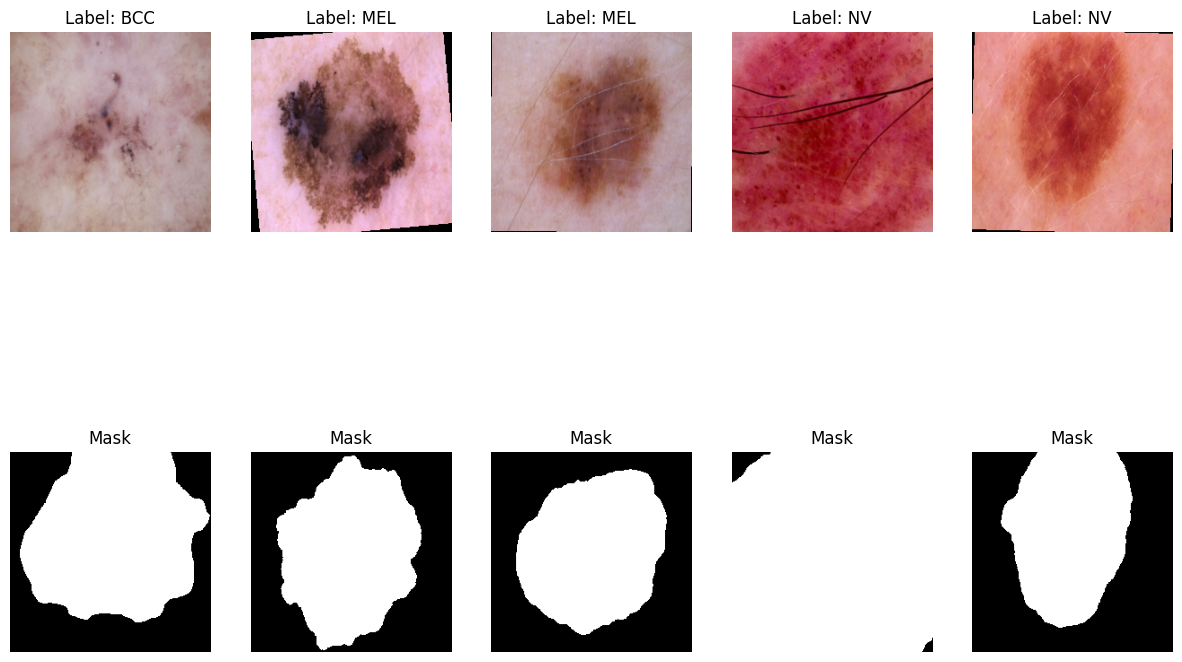

In [12]:
# Function to visualize images with their corresponding masks
def show_sample(dataset, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 10))

    for i in range(num_samples):
        img, mask, label = dataset[i]  # Unpack correctly
        img = img.permute(1, 2, 0).numpy()  # Convert (3, 224, 224) -> (224, 224, 3)
        mask = mask.squeeze(0).numpy()  # Convert (1, 224, 224) -> (224, 224)

        # Show image
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Label: {class_names[label]}")
        axes[0, i].axis("off")

        # Show corresponding mask
        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].set_title("Mask")
        axes[1, i].axis("off")

    plt.show()

# Show train samples
show_sample(train_dataset)


## Classification Model Definition and Training

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 101MB/s] 


Epoch [1/10] Loss: 1.1673, Accuracy: 60.81%
Epoch [2/10] Loss: 0.7556, Accuracy: 72.51%
Epoch [3/10] Loss: 0.5850, Accuracy: 76.36%
Epoch [4/10] Loss: 0.4672, Accuracy: 80.49%
Epoch [5/10] Loss: 0.4164, Accuracy: 82.05%
Epoch [6/10] Loss: 0.3460, Accuracy: 84.08%
Epoch [7/10] Loss: 0.2767, Accuracy: 86.85%
Epoch [8/10] Loss: 0.2733, Accuracy: 87.96%
Epoch [9/10] Loss: 0.2347, Accuracy: 88.70%
Epoch [10/10] Loss: 0.2087, Accuracy: 90.51%
Training Done!


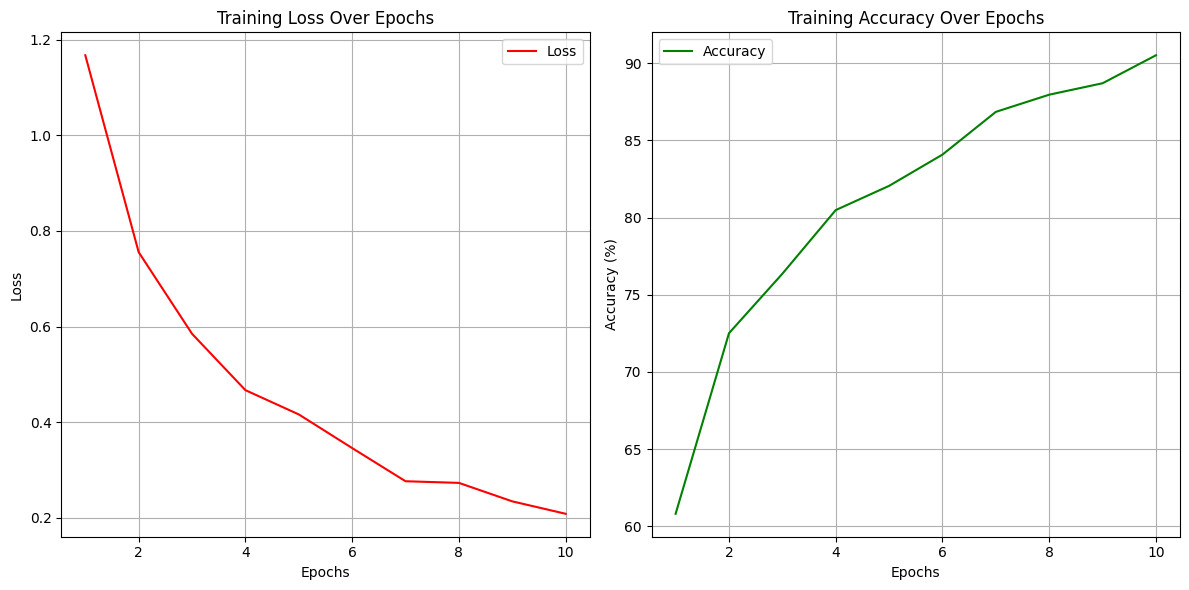

In [13]:
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt

# Pretrained ResNet18
resnet18 = models.resnet18(pretrained=True)

# Freeze all layers except for the last one (layer4)
for param in resnet18.parameters():
    param.requires_grad = False
for param in resnet18.layer4.parameters():
    param.requires_grad = True

# Modify the last fully connected layer to match the number of classes (7 classes for skin cancer)
num_classes = 7  # Number of classes (e.g., for skin cancer)
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

# Set the device (CUDA or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = resnet18.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_classification.to(device))  # Assuming class_weights_classification is defined
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet18.parameters()), lr=1e-4)

# Lists to track loss and accuracy
losses = []
accuracies = []

# Training Loop
for epoch in range(10):
    resnet18.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    for images, masks, labels in train_loader:  # images and labels for classification
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet18(images)

        # Compute loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        correct_preds += (predicted == labels).sum().item()
        total_preds += labels.size(0)

    # Calculate average loss and accuracy for the epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct_preds / total_preds * 100

    # Append the loss and accuracy for plotting
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/10] Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

print("Training Done!")

# Plotting Loss and Accuracy Graphs
epochs = range(1, 11)  # Assuming 10 epochs

# Plot Loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, losses, label='Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracies, label='Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
total_params = sum(p.numel() for p in resnet18.parameters())
print(f"Total Parameters: {total_params:,}")


Total Parameters: 11,180,103


 ## Classification Evaluation and Metrics

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
#import torch.nn.functional as F

resnet18.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, _, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = resnet18(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [16]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {accuracy*100:.2f}%")


Test Accuracy: 82.57%


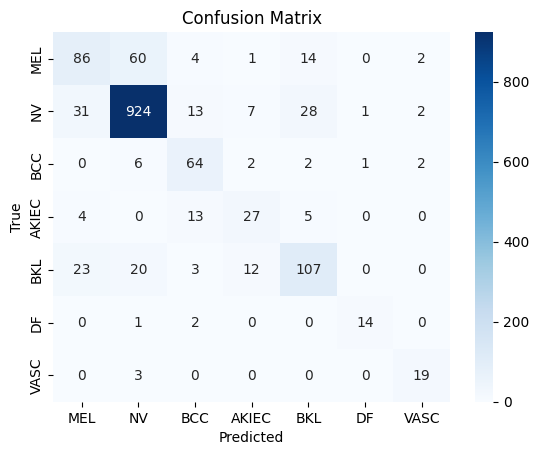

In [17]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [18]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

         MEL       0.60      0.51      0.55       167
          NV       0.91      0.92      0.91      1006
         BCC       0.65      0.83      0.73        77
       AKIEC       0.55      0.55      0.55        49
         BKL       0.69      0.65      0.67       165
          DF       0.88      0.82      0.85        17
        VASC       0.76      0.86      0.81        22

    accuracy                           0.83      1503
   macro avg       0.72      0.74      0.72      1503
weighted avg       0.82      0.83      0.82      1503



## UNet Model Definition

In [19]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # Encoder
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024, dropout=True)

        # Decoder
        self.upconv4 = self.upconv(1024, 512)
        self.dec4 = self.conv_block(1024, 512)

        self.upconv3 = self.upconv(512, 256)
        self.dec3 = self.conv_block(512, 256)

        self.upconv2 = self.upconv(256, 128)
        self.dec2 = self.conv_block(256, 128)

        self.upconv1 = self.upconv(128, 64)
        self.dec1 = self.conv_block(128, 64)

        # Final Convolution
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

        # Initialize weights
        self._initialize_weights()

    def conv_block(self, in_ch, out_ch, dropout=False):
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def upconv(self, in_ch, out_ch):
        return nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(nn.MaxPool2d(2)(e1))
        e3 = self.enc3(nn.MaxPool2d(2)(e2))
        e4 = self.enc4(nn.MaxPool2d(2)(e3))

        # Bottleneck
        b = self.bottleneck(nn.MaxPool2d(2)(e4))

        # Decoder
        d4 = self.upconv4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)  # No sigmoid for training

## UNet Training with Validation and Checkpointing


In [23]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Initialize model, loss, and optimizer
model = UNet(in_channels=3, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3)
criterion = nn.BCEWithLogitsLoss()

# Lists to track training and validation loss
train_losses = []
val_losses = []

# Training loop
num_epochs = 5
best_val_loss = float("inf")
for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for images, masks, labels in train_loader:
        images, masks = images.to(device), masks.to(device)
        #masks = masks.squeeze(1) 
        # Forward pass
        preds = model(images)
        loss = criterion(preds, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)  # Append training loss for the epoch

    # Validation loop
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for images, masks, labels in val_loader:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)
            epoch_val_loss += loss.item()

    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)  # Append validation loss for the epoch

    # Adjust learning rate based on validation loss
    scheduler.step(epoch_val_loss)

    # Save best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_unet.pth")

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}")



Epoch 1/5, Training Loss: 0.3038, Validation Loss: 0.3529
Epoch 2/5, Training Loss: 0.1864, Validation Loss: 0.1565
Epoch 3/5, Training Loss: 0.1568, Validation Loss: 0.1369
Epoch 4/5, Training Loss: 0.1456, Validation Loss: 0.1321
Epoch 5/5, Training Loss: 0.1370, Validation Loss: 0.1247


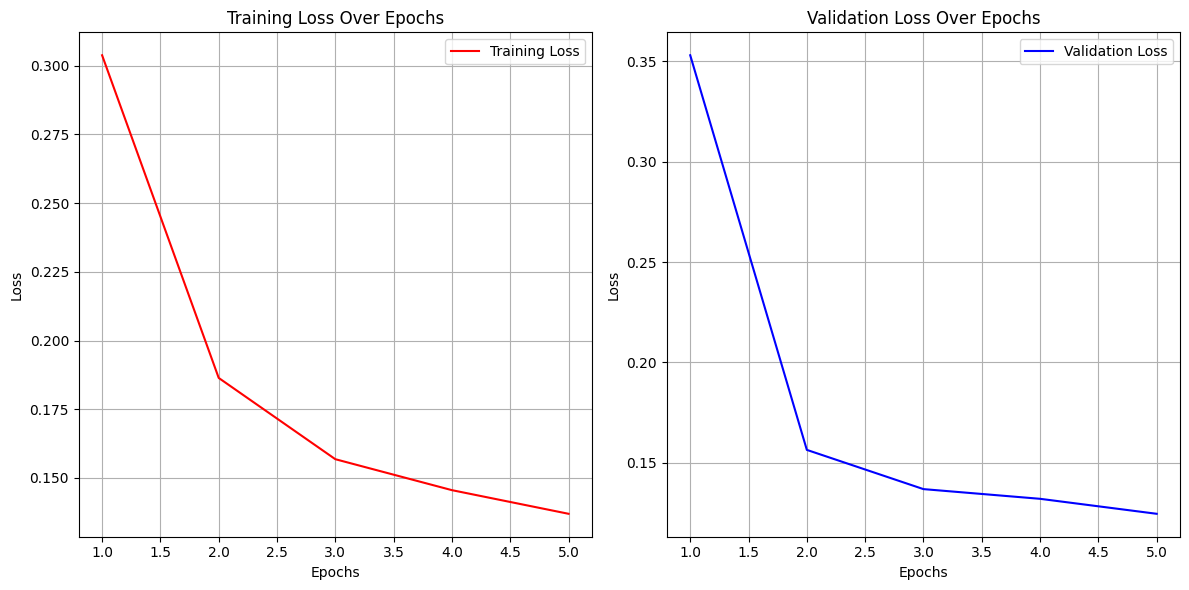

In [24]:
# Plotting Loss Graphs
epochs = range(1, num_epochs + 1)  # Number of epochs

# Plot Training Loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.legend()

# Plot Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, val_losses, label='Validation Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
model.load_state_dict(torch.load("best_unet.pth"))  # Load the best model weights
model.eval()  # Set the model to evaluation mode

/tmp/ipykernel_31/2932374324.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_unet.pth"))  # Load the best model weights


UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv

In [26]:
def compute_pixel_accuracy(preds, masks):
    correct = (preds == masks).float()
    acc = correct.sum() / correct.numel()
    return acc.item()


In [27]:
model.eval()
pixel_accuracies = []

with torch.no_grad():
    for images, masks, _ in test_loader:
        images = images.to(device)
        masks = masks.to(device).squeeze(1)  # shape: (B, H, W)

        outputs = model(images)  # (B, num_classes, H, W)
        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)  # shape: (B, H, W)

        acc = compute_pixel_accuracy(preds, masks)
        pixel_accuracies.append(acc)
   

# Final average pixel accuracy
mean_pixel_acc = sum(pixel_accuracies) / len(pixel_accuracies)
print(f"Pixel-wise Accuracy: {mean_pixel_acc:.4f}")


Pixel-wise Accuracy: 0.7370


## Segmentation Evaluation Metrics: IoU and Dice Score


In [31]:
import torch
import numpy as np

def compute_iou(preds, labels, num_classes=7):
    """Computes mean IoU score for multi-class segmentation."""
    iou_per_class = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        label_cls = (labels == cls).float()

        intersection = (pred_cls * label_cls).sum(dim=(1, 2))  # Intersection
        union = pred_cls.sum(dim=(1, 2)) + label_cls.sum(dim=(1, 2)) - intersection  # Union

        iou = (intersection + 1e-6) / (union + 1e-6)  # Avoid division by zero
        iou_per_class.append(iou.mean().item())

    return np.mean(iou_per_class)  # Mean IoU across all classes

def compute_dice(preds, labels, num_classes=7):
    """Computes mean Dice Score for multi-class segmentation."""
    dice_per_class = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        label_cls = (labels == cls).float()

        intersection = (pred_cls * label_cls).sum(dim=(1, 2))  # Intersection
        dice = (2. * intersection + 1e-6) / (pred_cls.sum(dim=(1, 2)) + label_cls.sum(dim=(1, 2)) + 1e-6)

        dice_per_class.append(dice.mean().item())

    return np.mean(dice_per_class)  # Mean Dice score across all classes

# Set model to evaluation mode
model.eval()
test_iou = []
test_dice = []

with torch.no_grad():
    for images, masks,labels in test_loader:
        images, masks = images.to(device), masks.to(device)
        masks = masks.squeeze(1)
        preds = model(images)  # Model output (B, 7, H, W)
        preds = torch.argmax(torch.softmax(preds, dim=1), dim=1)  # Convert logits to class indices

        # Compute IoU and Dice for the batch
        batch_iou = compute_iou(preds, masks, num_classes=7)
        batch_dice = compute_dice(preds, masks, num_classes=7)

        test_iou.append(batch_iou)
        test_dice.append(batch_dice)

# Compute average IoU and Dice over the entire test set
mean_iou = sum(test_iou) / len(test_iou)
mean_dice = sum(test_dice) / len(test_dice)

print(f"Test IoU: {mean_iou:.4f}, Test Dice Score: {mean_dice:.4f}")

Test IoU: 0.8196, Test Dice Score: 0.8331


Pred shape: torch.Size([1, 1, 224, 224])
Pred min: 0.0000, max: 0.9999, mean: 0.3224
Unique values in pred_mask: [0. 1.]


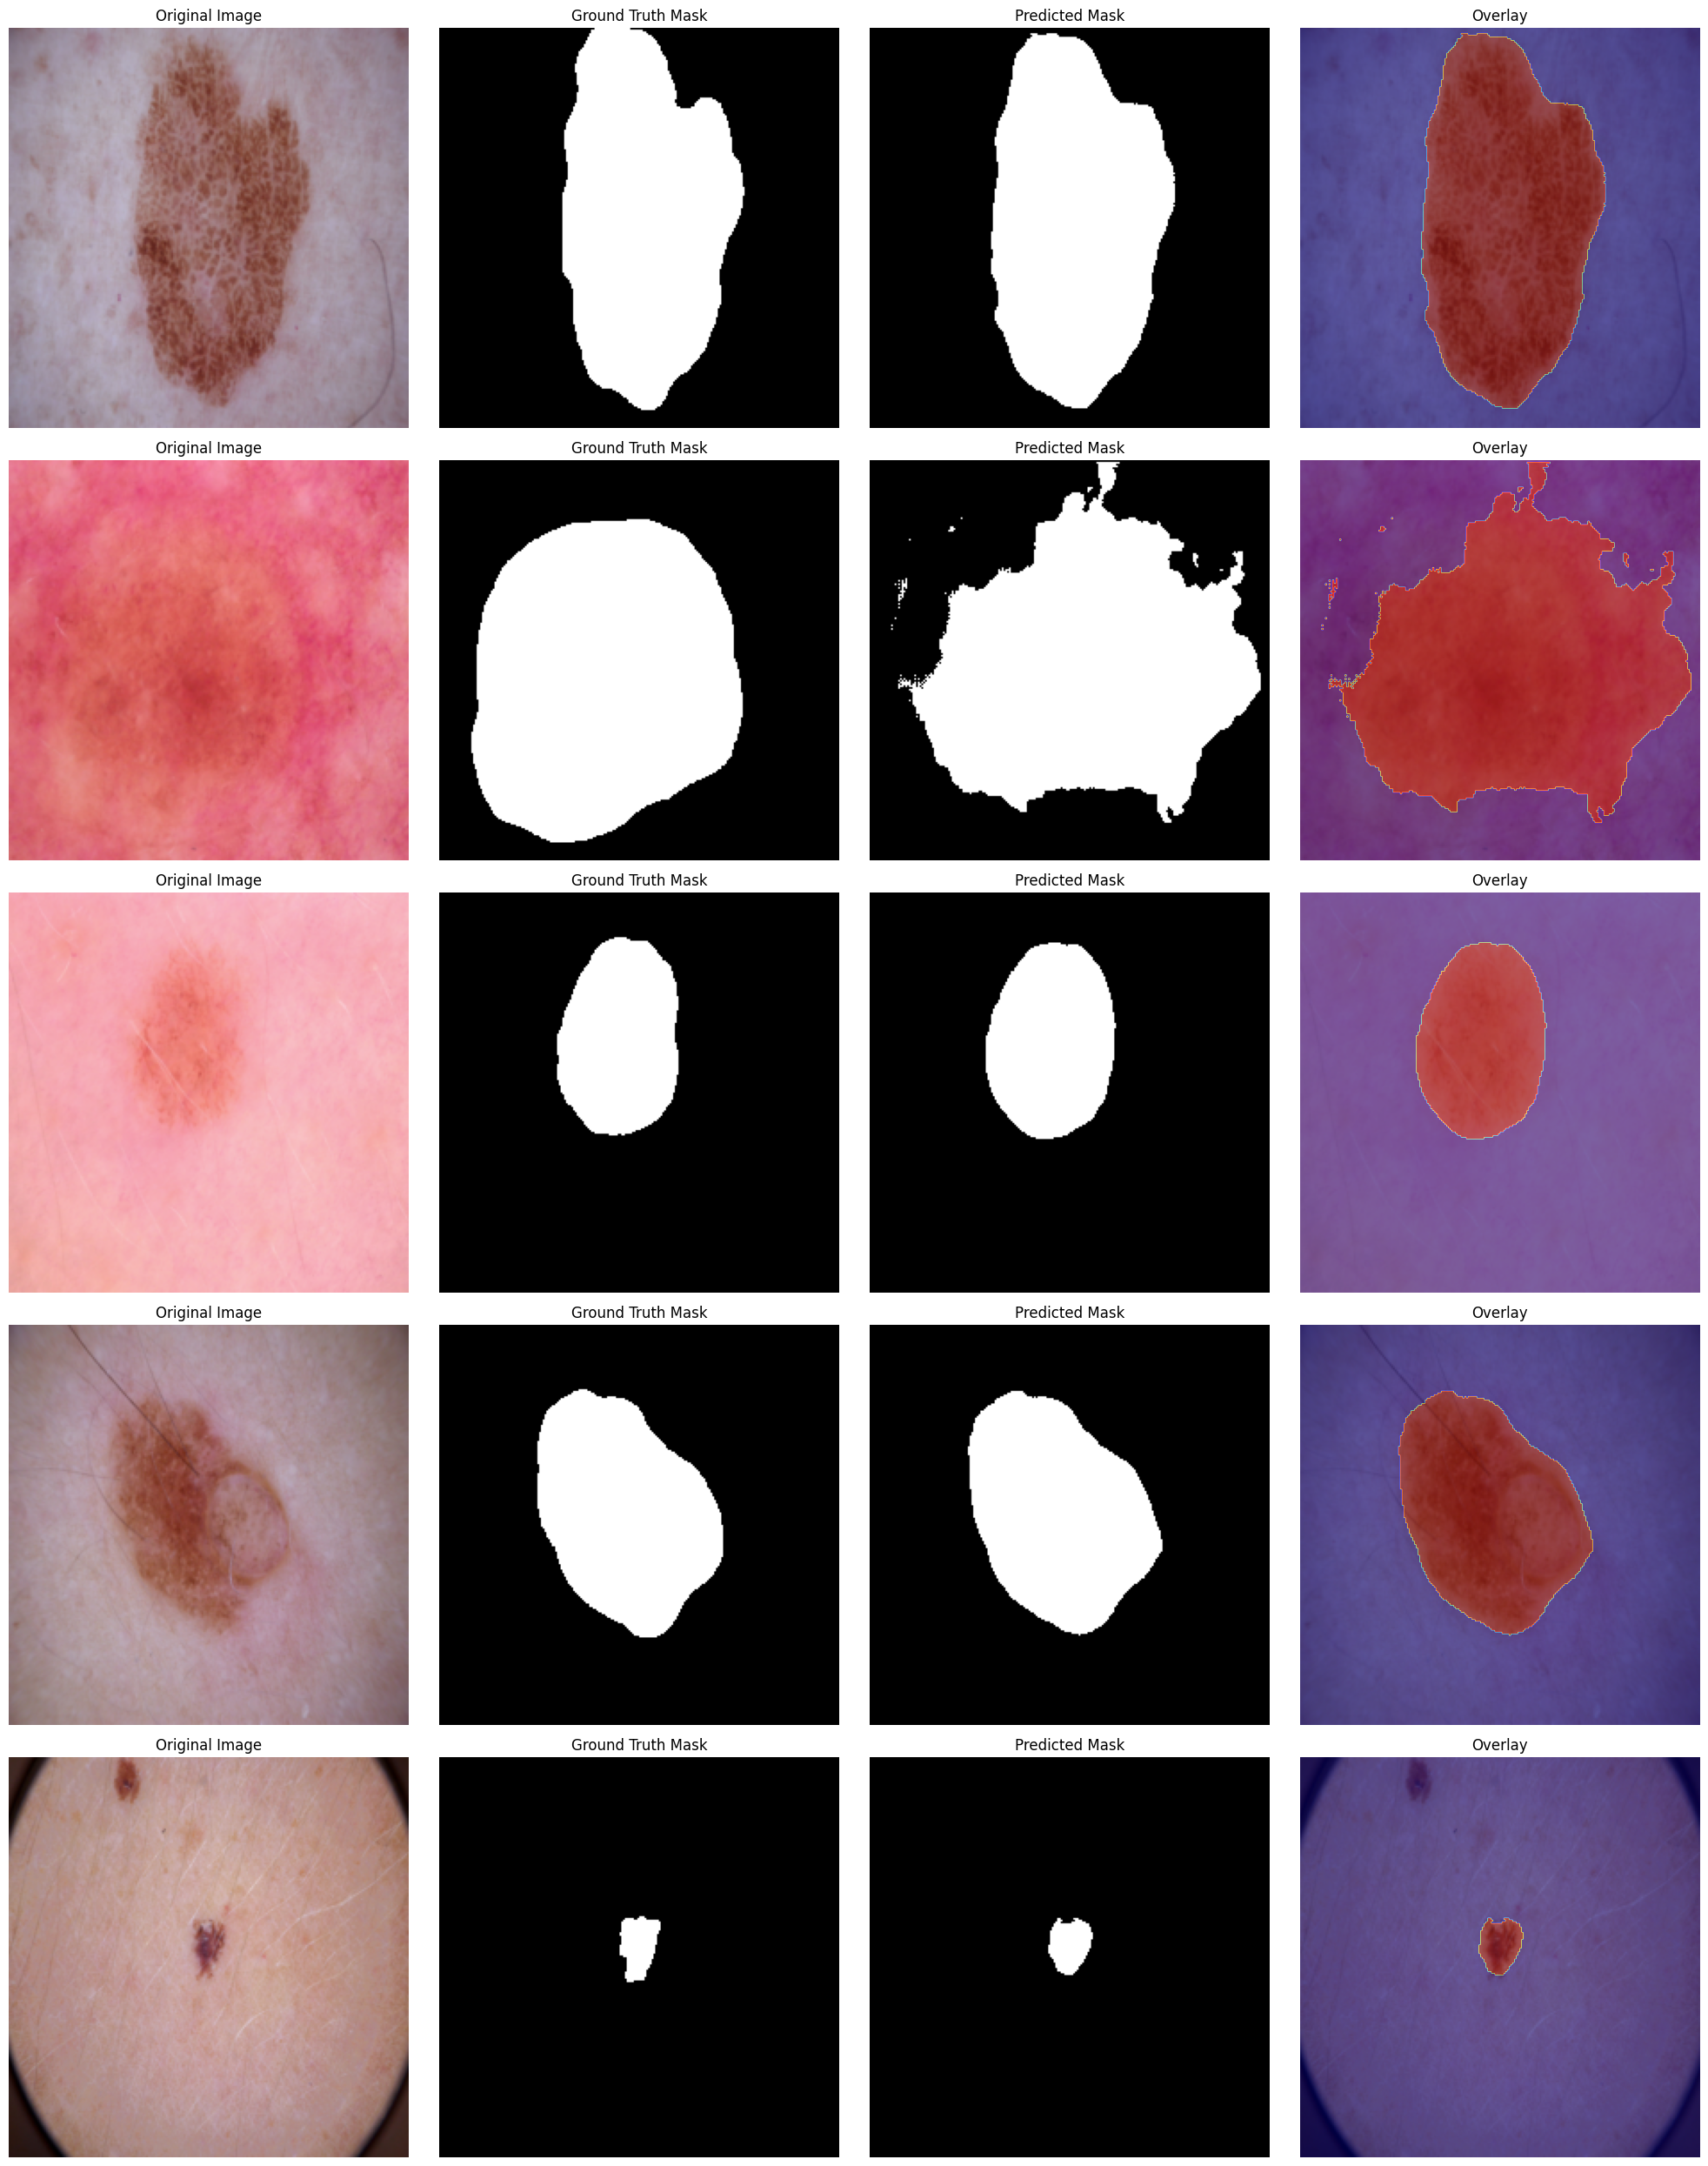

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_predictions(model, test_loader, device, num_samples=5, mean=None, std=None):
    model.eval()
    model.to(device)  # Ensure model is on the correct device
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

    # Handle single-sample display
    if num_samples == 1:
        axes = np.array([axes]).reshape(1, -1)

    # Iterate over test_loader directly
    sample_count = 0
    for batch in test_loader:
        if sample_count >= num_samples:
            break
        try:
            if len(batch) != 3:
                raise ValueError(f"Expected 3 items in batch, got {len(batch)}")
            img, mask, _ = batch  # Unpack list: images, masks, ignore labels
            img = img[0].unsqueeze(0).to(device)  # Take first sample
            mask = mask[0]  # Take first mask
        except ValueError as e:
            print(f"Error unpacking batch: {e}")
            print("Inspect test_loader output:")
            for j, item in enumerate(batch):
                print(f"Item {j} shape: {item.shape}")
            raise

        with torch.no_grad():
            pred = model(img)  # Shape: [1, 1, H, W]
            pred = torch.sigmoid(pred)  # Convert logits to probabilities
            pred_mask = (pred > 0.5).float().squeeze().cpu().numpy()  # Binarize and squeeze

        # Debugging for first sample
        if sample_count == 0:
            print(f"Pred shape: {pred.shape}")
            print(f"Pred min: {pred.min().item():.4f}, max: {pred.max().item():.4f}, mean: {pred.mean().item():.4f}")
            print(f"Unique values in pred_mask: {np.unique(pred_mask)}")

        # Convert image to NumPy and denormalize if necessary
        img_np = img.squeeze(0).permute(1, 2, 0).cpu().numpy()
        if mean is not None and std is not None:
            mean = np.array(mean)
            std = np.array(std)
            img_np = img_np * std + mean  # Denormalize
            img_np = np.clip(img_np, 0, 1)
        elif img_np.max() > 1:
            img_np /= 255.0  # Assume [0, 255] if not normalized

        # Handle mask shape
        if mask.dim() == 3:  # [C, H, W]
            true_mask = mask.squeeze(0).cpu().numpy()
        else:  # [H, W]
            true_mask = mask.cpu().numpy()

        # Plot original image
        axes[sample_count, 0].imshow(img_np)
        axes[sample_count, 0].set_title("Original Image")
        axes[sample_count, 0].axis("off")

        # Plot ground truth mask
        axes[sample_count, 1].imshow(true_mask, cmap="gray")
        axes[sample_count, 1].set_title("Ground Truth Mask")
        axes[sample_count, 1].axis("off")

        # Plot predicted mask
        axes[sample_count, 2].imshow(pred_mask, cmap="gray")
        axes[sample_count, 2].set_title("Predicted Mask")
        axes[sample_count, 2].axis("off")

        # Overlay predicted mask on original image
        axes[sample_count, 3].imshow(img_np)
        axes[sample_count, 3].imshow(pred_mask, cmap="jet", alpha=0.5)
        axes[sample_count, 3].set_title("Overlay")
        axes[sample_count, 3].axis("off")

        sample_count += 1

    if sample_count == 0:
        print("No samples processed. Check test_loader.")
        plt.close(fig)
        return

    plt.tight_layout()
    plt.savefig("predictions.png", bbox_inches="tight")
    plt.show()

# Example usage
# mean = [0.485, 0.456, 0.406]  # ImageNet mean
# std = [0.229, 0.224, 0.225]   # ImageNet std
mean = [0,0,0]  
std = [1,1,1]   
visualize_predictions(model, test_loader, device, num_samples=5, mean=mean, std=std)


Pixel-wise Accuracy: 94.89%


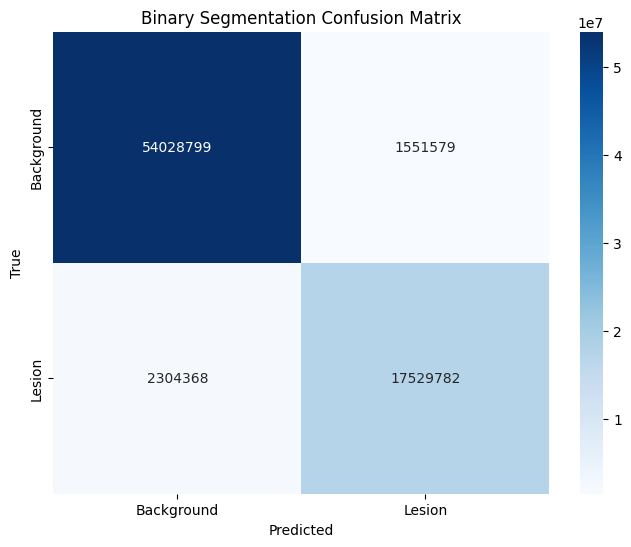

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def plot_segmentation_confusion_matrix(model, test_loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, masks, _ in test_loader:
            images = images.to(device)
            masks = masks.to(device).squeeze(1)  # Remove channel dim if [batch, 1, H, W]

            outputs = model(images)  # Shape: [batch, 1, H, W]
            preds = torch.sigmoid(outputs)  # Convert logits to probabilities
            preds = (preds > threshold).float()  # Binarize predictions

            # Flatten for pixel-wise comparison
            preds = preds.view(-1).cpu().numpy()
            masks = masks.view(-1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(masks)

    # Compute pixel-wise accuracy
    pixel_acc = accuracy_score(all_labels, all_preds)
    print(f"\nPixel-wise Accuracy: {pixel_acc * 100:.2f}%")

    # Compute and plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Background", "Lesion"],
                yticklabels=["Background", "Lesion"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Binary Segmentation Confusion Matrix")
    plt.show()

    return cm, pixel_acc

# Example usage
cm, pixel_acc = plot_segmentation_confusion_matrix(model, test_loader, device)

## Bonus 1

In [40]:
import torch
import torch.nn as nn

unet_path = "best_unet.pth"     

class CombinedModel(nn.Module):
    def __init__(self, unet_path =  "best_unet.pth", num_classes=7, device="cuda"):
        super(CombinedModel, self).__init__()

        # Load pre-trained ResNet18 model
        self.resnet = resnet18
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)  # Adjust final layer
        self.resnet.eval()  # Set to eval mode
        
        self.unet = UNet(in_channels=3, out_channels=1)
        # Load pre-trained U-Net model
        self.unet.load_state_dict(torch.load(unet_path, map_location=device))
        self.unet.eval()

    def forward(self, x):
        class_output = self.resnet(x)         # Shape: [B, 7]
        seg_output = self.unet(x)             # Shape: [B, 1, H, W]
        return class_output, seg_output



combined_model = CombinedModel(unet_path, num_classes=7, device=device).to(device)

/tmp/ipykernel_31/1065900289.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.unet.load_state_dict(torch.load(unet_path, map_location=device))


In [42]:
combined_model = CombinedModel(num_classes=7).to(device)
criterion_cls = nn.CrossEntropyLoss()
criterion_seg = nn.BCEWithLogitsLoss()# binary mask
optimizer = torch.optim.Adam(combined_model.parameters(), lr=1e-4)


/tmp/ipykernel_31/1065900289.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.unet.load_state_dict(torch.load(unet_path, map_location=device))


In [44]:
import matplotlib.pyplot as plt

train_losses = []
train_cls_accuracies = []


num_epochs = 10
combined_model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    total_cls_correct = 0
    total_cls_samples = 0

    for images, masks, labels in train_loader:
        images = images.to(device)
        masks = masks.to(device).float()
        labels = labels.to(device).long()

        optimizer.zero_grad()

        # Forward
        class_output, seg_output = combined_model(images)

        # Losses
        loss_cls = criterion_cls(class_output, labels)
        seg_output = seg_output.squeeze(1)
        masks = masks.squeeze(1)
        loss_seg = criterion_seg(seg_output, masks)

        loss = loss_cls + loss_seg
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Classification Accuracy
        _, preds = torch.max(class_output, dim=1)
        total_cls_correct += (preds == labels).sum().item()
        total_cls_samples += labels.size(0)

    # Log for this epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = total_cls_correct / total_cls_samples

    train_losses.append(epoch_loss)
    train_cls_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}  |  Accuracy: {epoch_acc:.4f}")



Epoch [1/10] Loss: 0.4756  |  Accuracy: 0.8792
Epoch [2/10] Loss: 0.3074  |  Accuracy: 0.9308
Epoch [3/10] Loss: 0.2512  |  Accuracy: 0.9511
Epoch [4/10] Loss: 0.2315  |  Accuracy: 0.9553
Epoch [5/10] Loss: 0.2043  |  Accuracy: 0.9660
Epoch [6/10] Loss: 0.2066  |  Accuracy: 0.9606
Epoch [7/10] Loss: 0.1918  |  Accuracy: 0.9710
Epoch [8/10] Loss: 0.1784  |  Accuracy: 0.9765
Epoch [9/10] Loss: 0.1755  |  Accuracy: 0.9732
Epoch [10/10] Loss: 0.1660  |  Accuracy: 0.9793


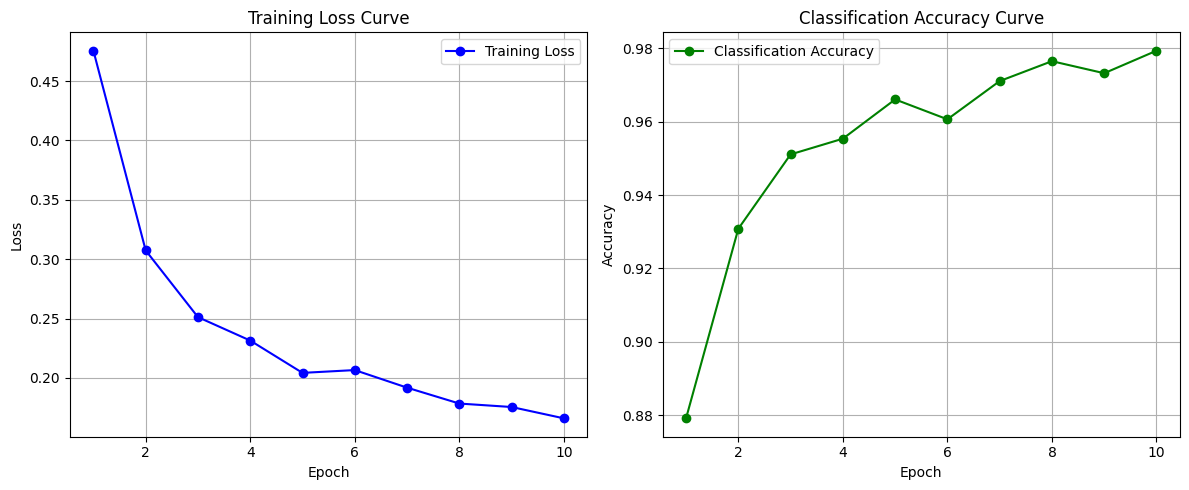

In [45]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs, train_cls_accuracies, 'g-o', label='Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Curve')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


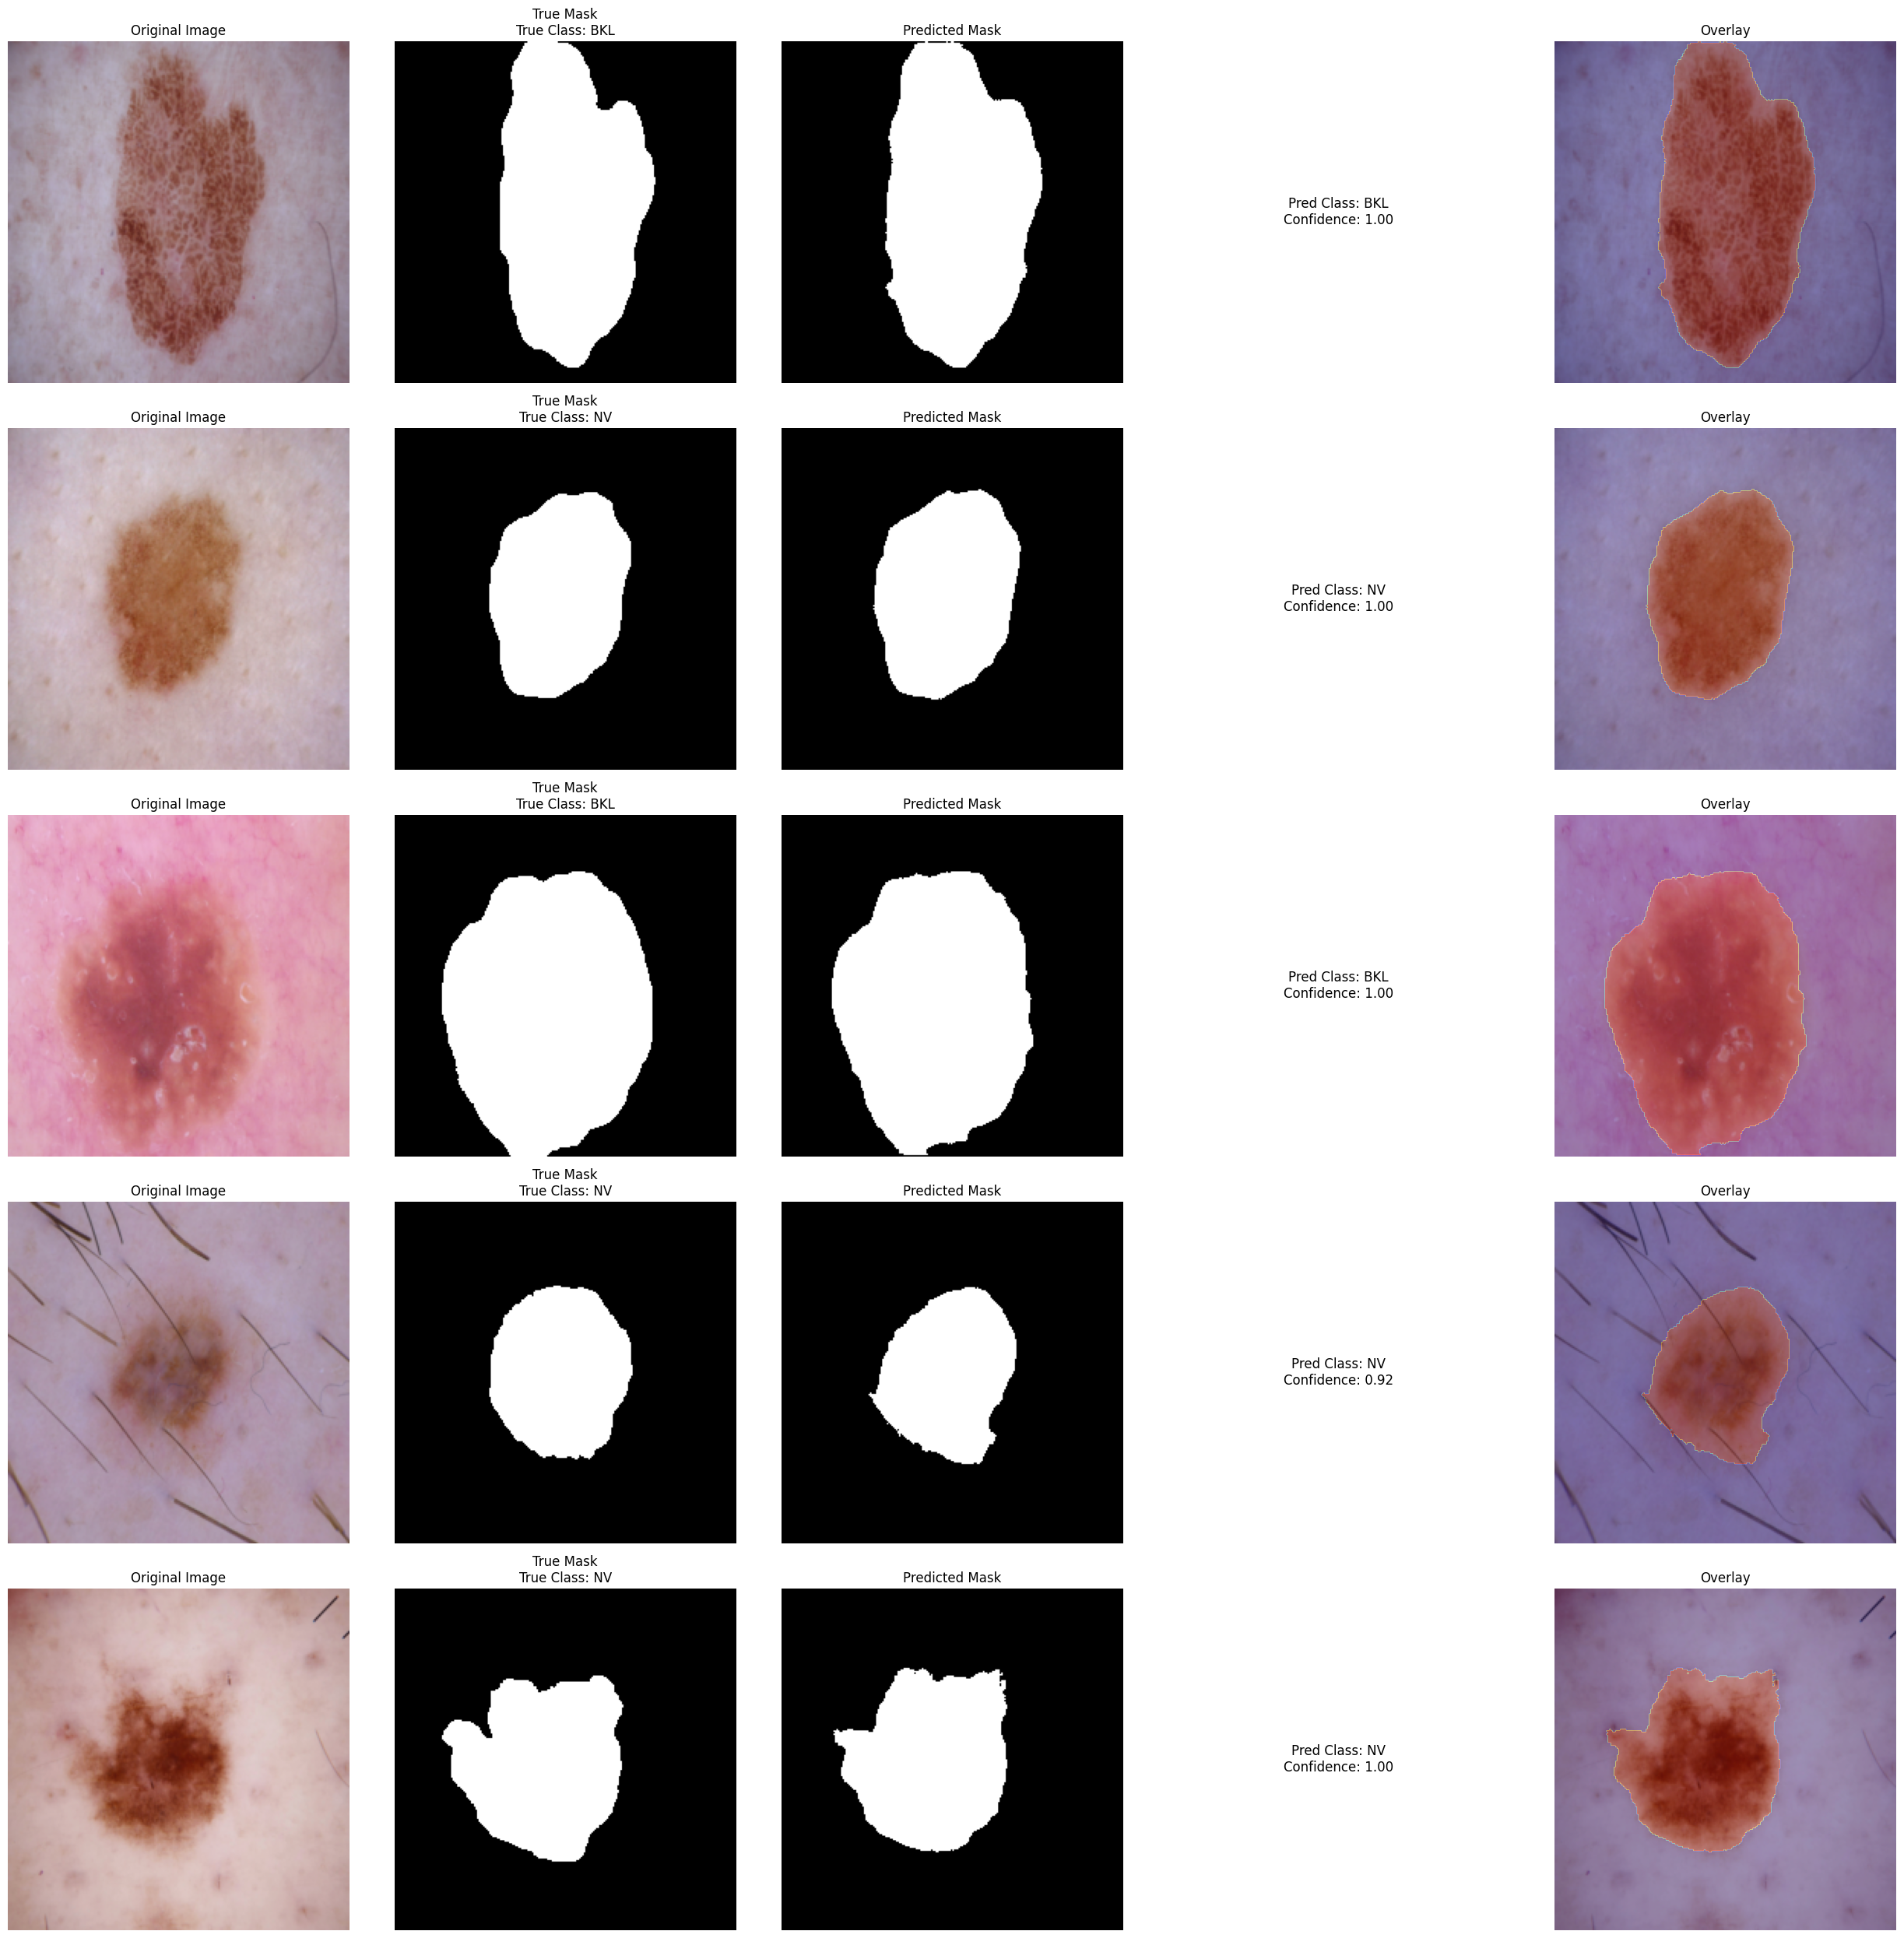

In [48]:
def visualize_multi_task_predictions(combined_model, test_dataset, device, num_samples=5):
    combined_model.eval()
    fig, axes = plt.subplots(num_samples, 5, figsize=(25, 5*num_samples))

    for i in range(num_samples):
        img, mask, true_label = test_dataset[i]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            class_output, seg_output = combined_model(img)
            pred_mask = torch.sigmoid(seg_output).squeeze(0).squeeze(0).cpu().numpy()
            pred_class = torch.softmax(class_output, dim=1).argmax(dim=1).item()
            prob = torch.softmax(class_output, dim=1).max(dim=1).values.item()

        img_np = img.squeeze(0).permute(1, 2, 0).cpu().numpy()
        true_mask = mask.squeeze(0).cpu().numpy()

        # Original Image
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        # Ground Truth Mask
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title(f"True Mask\nTrue Class: {class_names[true_label]}")
        axes[i, 1].axis("off")

        # Predicted Mask (Binary)
        axes[i, 2].imshow(pred_mask > 0.5, cmap="gray")  # Threshold at 0.5
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")

        # Predicted Class
        axes[i, 3].text(0.5, 0.5,
                       f"Pred Class: {class_names[pred_class]}\nConfidence: {prob:.2f}",
                       ha='center', va='center', fontsize=12)
        axes[i, 3].axis("off")

        # Overlay
        axes[i, 4].imshow(img_np)
        axes[i, 4].imshow(pred_mask > 0.5, cmap="jet", alpha=0.3)
        axes[i, 4].set_title("Overlay")
        axes[i, 4].axis("off")

    plt.tight_layout()
    plt.show()

visualize_multi_task_predictions(combined_model, test_dataset, device, num_samples=5)


Classification Accuracy: 83.10%


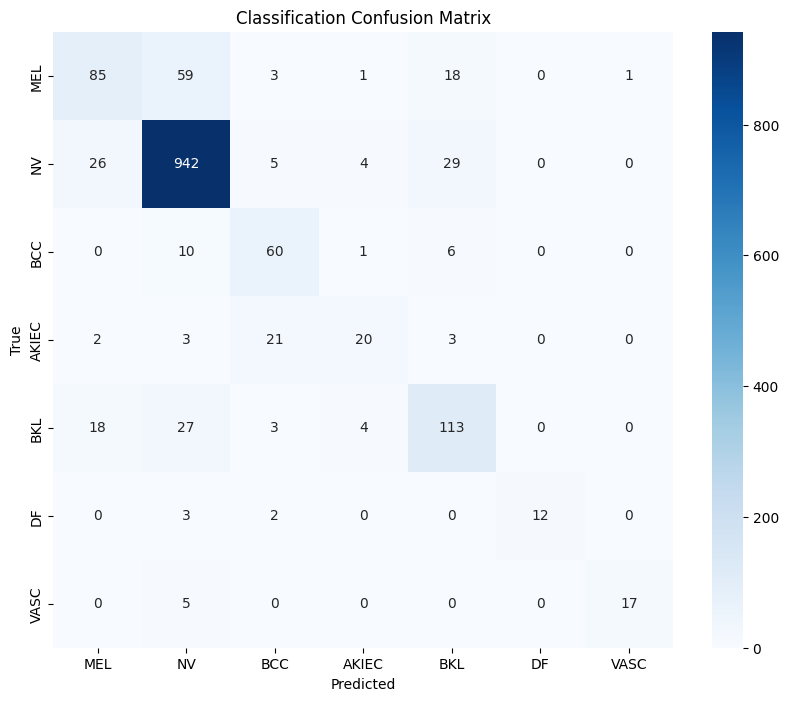

In [51]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

def plot_classification_confusion_matrix(combined_model, test_loader, device, class_names):
    combined_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, _, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            class_output, _ = combined_model(images)
            preds = torch.argmax(class_output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute accuracy
    acc = accuracy_score(all_labels, all_preds)
    print(f"\nClassification Accuracy: {acc * 100:.2f}%")

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plot confusion matrix using Seaborn heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Classification Confusion Matrix")
    plt.show()

plot_classification_confusion_matrix(combined_model, test_loader, device, class_names)



Segmentation Accuracy: 95.86%


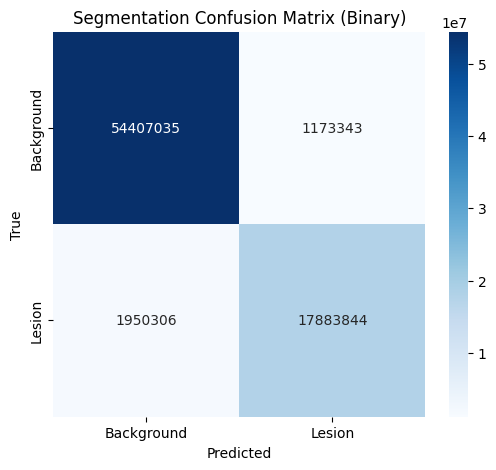

In [52]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

def plot_segmentation_confusion_matrix(combined_model, test_loader, device):
    combined_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, masks, _ in test_loader:
            images, masks = images.to(device), masks.to(device)
            _, seg_output = combined_model(images)
            
            # Apply sigmoid activation for binary classification and threshold at 0.5
            preds = (torch.sigmoid(seg_output) > 0.5).float()
            
            # Flatten the masks and predictions
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(masks.cpu().numpy().flatten())

    # Compute accuracy
    acc = accuracy_score(all_labels, all_preds)
    print(f"\nSegmentation Accuracy: {acc * 100:.2f}%")

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix using Seaborn heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Background", "Lesion"],
                yticklabels=["Background", "Lesion"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Segmentation Confusion Matrix (Binary)")
    plt.show()


plot_segmentation_confusion_matrix(combined_model, test_loader, device)


In [53]:
from sklearn.metrics import classification_report

def print_classification_report(combined_model, test_loader, device):
    combined_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, _, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            class_output, _ = combined_model(images)
            preds = torch.argmax(class_output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))

print_classification_report(combined_model, test_loader, device)

              precision    recall  f1-score   support

         MEL       0.65      0.51      0.57       167
          NV       0.90      0.94      0.92      1006
         BCC       0.64      0.78      0.70        77
       AKIEC       0.67      0.41      0.51        49
         BKL       0.67      0.68      0.68       165
          DF       1.00      0.71      0.83        17
        VASC       0.94      0.77      0.85        22

    accuracy                           0.83      1503
   macro avg       0.78      0.69      0.72      1503
weighted avg       0.83      0.83      0.83      1503

